In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kazanova/sentiment140/training.1600000.processed.noemoticon.csv


In [3]:
df = pd.read_csv("/kaggle/input/datasets/kazanova/sentiment140/training.1600000.processed.noemoticon.csv", 
                 encoding='latin-1')
df.head(60)

,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew
5,0,1467811592,Mon Apr 06 22:20:03 PDT 2009,NO_QUERY,mybirch,Need a hug
6,0,1467811594,Mon Apr 06 22:20:03 PDT 2009,NO_QUERY,coZZ,@LOLTrish hey long time no see! Yes.. Rains a...
7,0,1467811795,Mon Apr 06 22:20:05 PDT 2009,NO_QUERY,2Hood4Hollywood,@Tatiana_K nope they didn't have it
8,0,1467812025,Mon Apr 06 22:20:09 PDT 2009,NO_QUERY,mimismo,@twittera que me muera ?
9,0,1467812416,Mon Apr 06 22:20:16 PDT 2009,NO_QUERY,erinx3leannexo,spring break in plain city... it's snowing


In [4]:
df = pd.read_csv("/kaggle/input/datasets/kazanova/sentiment140/training.1600000.processed.noemoticon.csv", 
                 encoding='latin-1', header=None)

df.columns = ['sentiment', 'id', 'date', 'query', 'user', 'text']

df.head()

,sentiment,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [5]:
df['sentiment'] = df['sentiment'].map({0: 'Negative', 4: 'Positive'})


df = df[['sentiment', 'text']]

print(df.shape)
print(df['sentiment'].value_counts())

(1600000, 2)
sentiment
Negative    800000
Positive    800000
Name: count, dtype: int64


In [6]:
df = df.sample(n=50000, random_state=42)
df.reset_index(drop=True, inplace=True)
print(df.shape)

(50000, 2)


In [7]:
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Error loading stopwords: <urlopen error [Errno -3]
[nltk_data]     Temporary failure in name resolution>


In [8]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'@\w+', '', text)                 
    text = re.sub(r'http\S+|www\S+', '', text)       
    text = re.sub(r'#(\w+)', r'\1', text)             
    text = re.sub(r'[^a-zA-Z\s]', '', text)           
    text = re.sub(r'\s+', ' ', text).strip()          
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]  
    return ' '.join(tokens)

In [9]:
df['clean_text'] = df['text'].apply(clean_text)

df[['text', 'clean_text']].head(10)

,text,clean_text
0,@chrishasboobs AHHH I HOPE YOUR OK!!!,ahhh hope ok
1,"@misstoriblack cool , i have no tweet apps fo...",cool tweet apps razr
2,@TiannaChaos i know just family drama. its la...,know family drama lamehey next time u hang kim...
3,School email won't open and I have geography ...,school email wont open geography stuff revise ...
4,upper airways problem,upper airways problem
5,Going to miss Pastor's sermon on Faith...,going miss pastors sermon faith
6,on lunch....dj should come eat with me,lunchdj come eat
7,@piginthepoke oh why are you feeling like that?,oh feeling like
8,gahh noo!peyton needs to live!this is horrible,gahh noopeyton needs livethis horrible
9,@mrstessyman thank you glad you like it! There...,thank glad like product review bit site enjoy ...


In [10]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

def get_sentiment_vader(text):
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

def get_compound_score(text):
    return sia.polarity_scores(text)['compound']

df['vader_sentiment'] = df['clean_text'].apply(get_sentiment_vader)
df['compound_score'] = df['clean_text'].apply(get_compound_score)

print(df['vader_sentiment'].value_counts())
df[['text', 'vader_sentiment', 'compound_score']].head(10)

[nltk_data] Error loading vader_lexicon: <urlopen error [Errno -3]
[nltk_data]     Temporary failure in name resolution>


vader_sentiment
Positive    23816
Neutral     14099
Negative    12085
Name: count, dtype: int64


,text,vader_sentiment,compound_score
0,@chrishasboobs AHHH I HOPE YOUR OK!!!,Positive,0.6249
1,"@misstoriblack cool , i have no tweet apps fo...",Positive,0.3182
2,@TiannaChaos i know just family drama. its la...,Negative,-0.0772
3,School email won't open and I have geography ...,Negative,-0.5267
4,upper airways problem,Negative,-0.4019
5,Going to miss Pastor's sermon on Faith...,Positive,0.2960
6,on lunch....dj should come eat with me,Neutral,0.0000
7,@piginthepoke oh why are you feeling like that?,Positive,0.4588
8,gahh noo!peyton needs to live!this is horrible,Negative,-0.5423
9,@mrstessyman thank you glad you like it! There...,Positive,0.8807


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

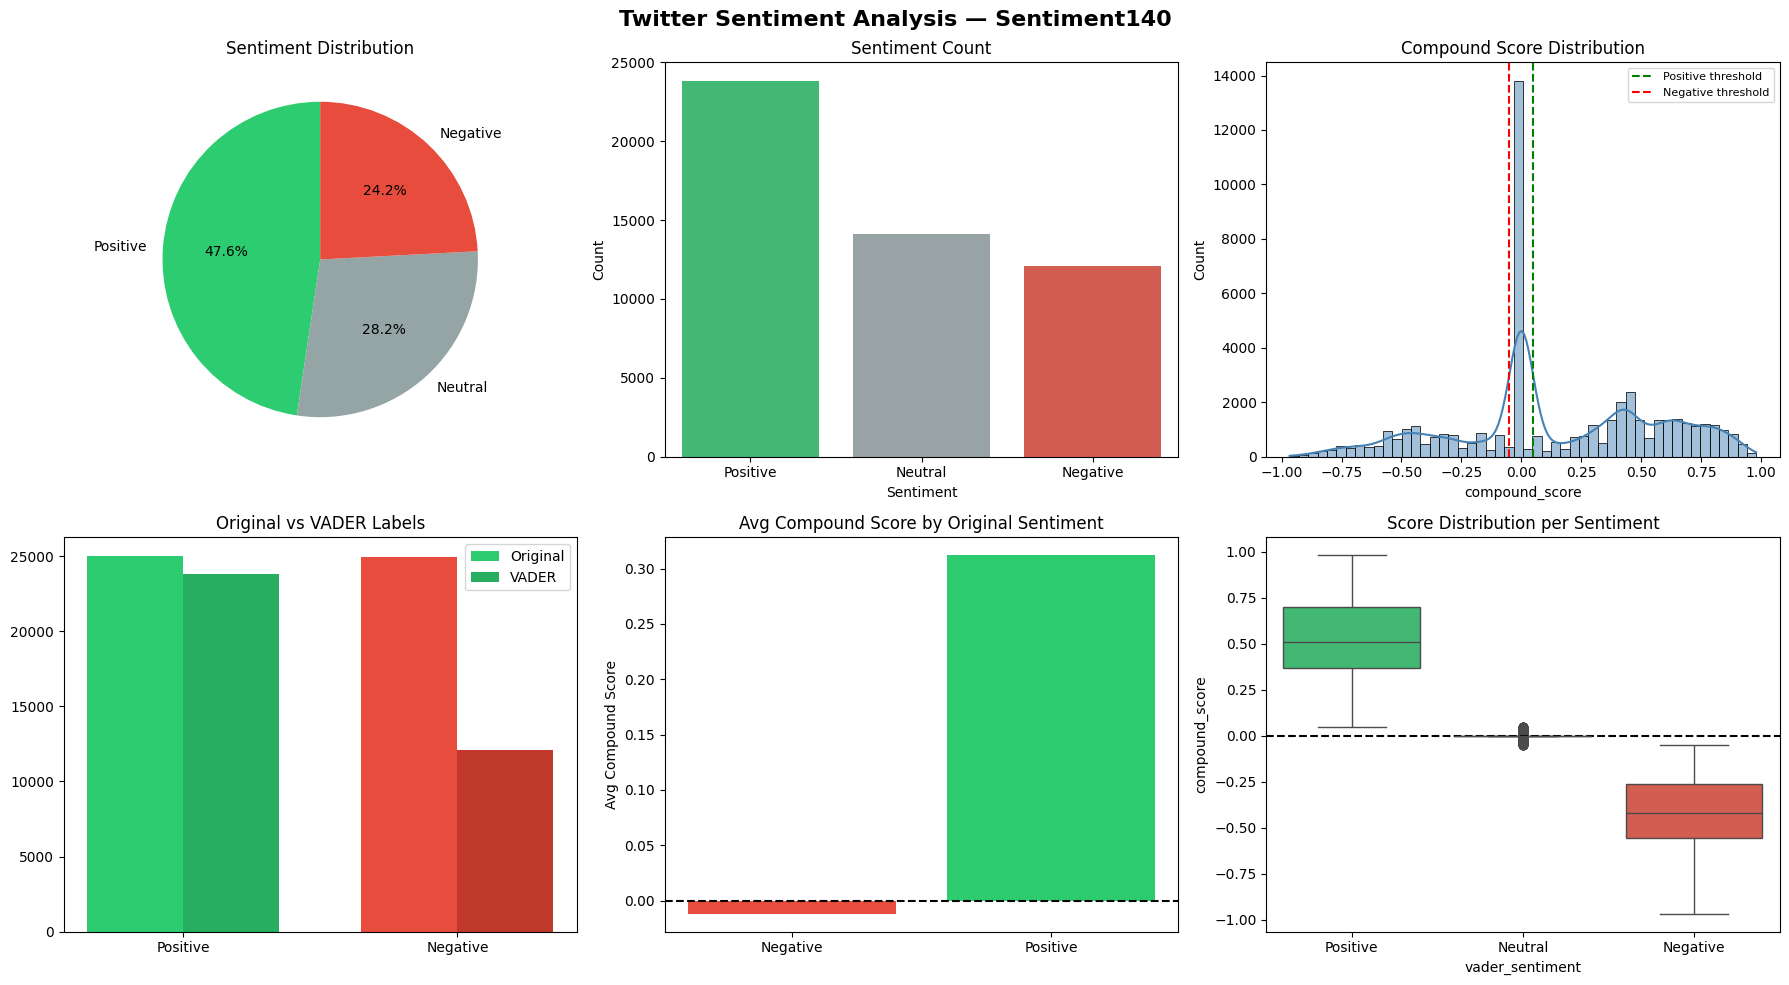

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Twitter Sentiment Analysis — Sentiment140', fontsize=16, fontweight='bold')

# 1. Pie Chart
sentiment_counts = df['vader_sentiment'].value_counts()
axes[0,0].pie(sentiment_counts, labels=sentiment_counts.index,
              autopct='%1.1f%%', colors=['#2ecc71','#95a5a6','#e74c3c'],
              startangle=90)
axes[0,0].set_title('Sentiment Distribution')

# 2. Bar Chart
sns.countplot(x='vader_sentiment', data=df, ax=axes[0,1], hue='vader_sentiment', legend=False,
              palette={'Positive':'#2ecc71','Negative':'#e74c3c','Neutral':'#95a5a6'},
              order=['Positive','Neutral','Negative'])
axes[0,1].set_title('Sentiment Count')
axes[0,1].set_xlabel('Sentiment')
axes[0,1].set_ylabel('Count')

# 3. Compound Score Distribution
sns.histplot(df['compound_score'], bins=50, kde=True, ax=axes[0,2], color='steelblue')
axes[0,2].axvline(0.05, color='green', linestyle='--', label='Positive threshold')
axes[0,2].axvline(-0.05, color='red', linestyle='--', label='Negative threshold')
axes[0,2].set_title('Compound Score Distribution')
axes[0,2].legend(fontsize=8)

# 4. Original vs VADER Sentiment Comparison
original = df['sentiment'].value_counts()
vader = df['vader_sentiment'].value_counts()
x = range(2)
width = 0.35
axes[1,0].bar([i - width/2 for i in x], 
              [original.get('Positive',0), original.get('Negative',0)],
              width, label='Original', color=['#2ecc71','#e74c3c'])
axes[1,0].bar([i + width/2 for i in x],
              [vader.get('Positive',0), vader.get('Negative',0)],
              width, label='VADER', color=['#27ae60','#c0392b'])
axes[1,0].set_xticks(list(x))
axes[1,0].set_xticklabels(['Positive','Negative'])
axes[1,0].set_title('Original vs VADER Labels')
axes[1,0].legend()

# 5. Avg Compound Score by Original Sentiment
avg_scores = df.groupby('sentiment')['compound_score'].mean()
axes[1,1].bar(avg_scores.index, avg_scores.values,
              color=['#e74c3c','#2ecc71'])
axes[1,1].set_title('Avg Compound Score by Original Sentiment')
axes[1,1].set_ylabel('Avg Compound Score')
axes[1,1].axhline(0, color='black', linestyle='--')

# 6. Score Boxplot
sns.boxplot(x='vader_sentiment', y='compound_score', data=df,
            ax=axes[1,2], hue='vader_sentiment', legend=False,
            palette={'Positive':'#2ecc71','Negative':'#e74c3c','Neutral':'#95a5a6'},
            order=['Positive','Neutral','Negative'])
axes[1,2].set_title('Score Distribution per Sentiment')
axes[1,2].axhline(0, color='black', linestyle='--')

plt.tight_layout()
plt.savefig('sentiment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


In [15]:
import os
os.listdir()

['.virtual_documents', 'wordcloud.png', 'sentiment_analysis.png']

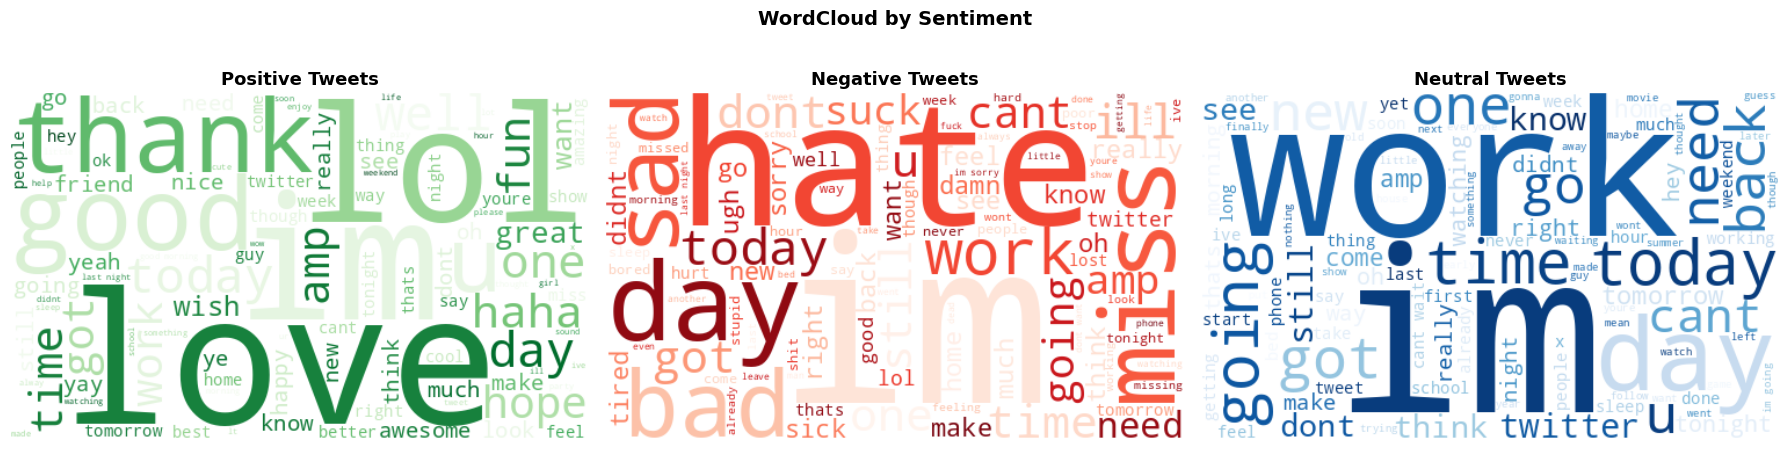

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('WordCloud by Sentiment', fontsize=14, fontweight='bold')

for ax, sentiment, colormap in zip(axes,
    ['Positive', 'Negative', 'Neutral'],
    ['Greens', 'Reds', 'Blues']):
    
    text = ' '.join(df[df['vader_sentiment'] == sentiment]['clean_text'])
    wc = WordCloud(width=500, height=300, 
                   background_color='white',
                   colormap=colormap, 
                   max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{sentiment} Tweets', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

## 📊 Twitter Sentiment Analysis — Key Insights

### Dataset Overview
- **Source:** Sentiment140 — Twitter Social Media Data
- **Total Tweets Analyzed:** 50,000 (sampled from 1.6M)
- **NLP Method:** VADER (Valence Aware Dictionary and sEntiment Reasoner)

### Sentiment Distribution
- 🟢 **Positive:** 47.6% — Nearly half of tweets show positive tone
- ⚪ **Neutral:** 28.2% — Casual or informational tweets
- 🔴 **Negative:** 24.2% — Complaints, sadness, frustration

### Emotion Patterns (WordCloud Findings)
- **Positive tweets** use words like: *love, good, great, well, happy*
- **Negative tweets** use words like: *hate, miss, ill, tired, suck, cant*
- **Neutral tweets** use words like: *work, today, time, going, still*

### Marketing & Business Insights
- Majority of public tweets are **positive** — good signal for brand monitoring
- Words like **"miss"** and **"hate"** in negative tweets suggest emotional frustration — 
  brands should monitor these for **customer dissatisfaction alerts**
- **"work"** appearing in neutral tweets shows daily life discussion dominates Twitter

### Product Development Insights
- Negative sentiment spikes around **personal struggles** — 
  mental health apps or productivity tools could target this audience
- Positive sentiment around **social connection** words (love, friend, good) —
  social platforms should amplify these experiences

### Conclusion
> VADER effectively classifies Twitter sentiment with clear separation between 
> positive and negative compound scores. Social media sentiment analysis provides 
> valuable real-time insights into public mood and trends.